In [8]:
import pandas as pd
import yfinance as yf
tickers = [
    "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", 
    "TECHM.NS", "LTM.NS", "PERSISTENT.NS", "COFORGE.NS"]
all_companies = []
for ticker in tickers:
    stock = yf.Ticker(ticker)
    info = stock.info
    price = info.get("currentPrice")
    eps = info.get("trailingEps")
    bvps = info.get("bookValue")
    total_revenue = info.get("totalRevenue")
    shares_outstanding = info.get("sharesOutstanding")
    ev_ebitda = info.get("enterpriseToEbitda")
    sales_per_share = total_revenue / shares_outstanding
    pe_ratio = price / eps
    pb_ratio = price / bvps
    ps_ratio = price / sales_per_share
    company_data = {
        "Ticker": ticker.replace(".NS", ""),
        "P/E": pe_ratio,
        "EV/EBITDA": ev_ebitda,
        "P/B": pb_ratio,
        "P/S": ps_ratio}
    all_companies.append(company_data)
df = pd.DataFrame(all_companies)
pe_median = df["P/E"].median()
ev_median = df["EV/EBITDA"].median()
pb_median = df["P/B"].median()
ps_median = df["P/S"].median()
pe_flags = []
ev_flags = []
pb_flags = []
ps_flags = []

for idx, row in df.iterrows():
    if row["P/E"] > pe_median:
        pe_flags.append("ABOVE Median")
    else:
        pe_flags.append("BELOW Median")
    if row["EV/EBITDA"] > ev_median:
        ev_flags.append("ABOVE Median")
    else:
        ev_flags.append("BELOW Median")
    if row["P/B"] > pb_median:
        pb_flags.append("ABOVE Median")
    else:
        pb_flags.append("BELOW Median")
    if row["P/S"] > ps_median:
        ps_flags.append("ABOVE Median")
    else:
        ps_flags.append("BELOW Median")
df["P/E Flag"] = pe_flags
df["EV/EBITDA Flag"] = ev_flags
df["P/B Flag"] = pb_flags
df["P/S Flag"] = ps_flags
median_row = {
    "Ticker": "MEDIAN BENCHMARK",
    "P/E": pe_median, "P/E Flag": "-",
    "EV/EBITDA": ev_median, "EV/EBITDA Flag": "-",
    "P/B": pb_median, "P/B Flag": "-",
    "P/S": ps_median, "P/S Flag": "-"}
final_table = pd.concat([df, pd.DataFrame([median_row])], ignore_index=True)
print("\n=== FINAL VALUATION REPORT ===")
print(final_table.round(2).to_string(index=False))


=== FINAL VALUATION REPORT ===
          Ticker   P/E  EV/EBITDA  P/B    P/S     P/E Flag EV/EBITDA Flag     P/B Flag     P/S Flag
             TCS 15.65      10.48 7.18   2.88 BELOW Median   BELOW Median ABOVE Median BELOW Median
            INFY 14.04     960.31 4.62 213.98 BELOW Median   ABOVE Median BELOW Median ABOVE Median
         HCLTECH 18.43    1055.72 4.06 208.60 BELOW Median   ABOVE Median BELOW Median ABOVE Median
           WIPRO 14.33       9.09 2.13   2.04 BELOW Median   BELOW Median BELOW Median BELOW Median
           TECHM 26.51      13.19 4.30   2.24 ABOVE Median   BELOW Median BELOW Median BELOW Median
             LTM 22.66      14.42 4.73   2.68 ABOVE Median   BELOW Median ABOVE Median BELOW Median
      PERSISTENT 40.92      26.43 9.70   5.15 ABOVE Median   ABOVE Median ABOVE Median ABOVE Median
         COFORGE 33.80      16.06 5.23   4.00 ABOVE Median   ABOVE Median ABOVE Median ABOVE Median
MEDIAN BENCHMARK 20.55      15.24 4.68   3.44            -          

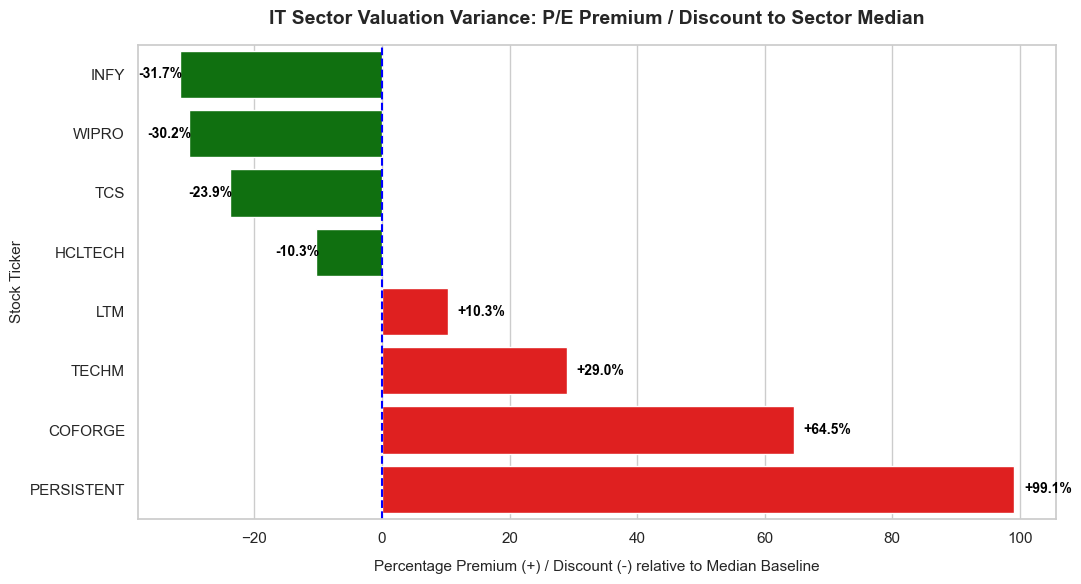

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
df["P/E Variance (%)"] = ((df["P/E"] - pe_median) / pe_median) * 100
df_sorted = df.sort_values(by="P/E Variance (%)").reset_index(drop=True)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))
colors = ["green" if val < 0 else "red" for val in df_sorted["P/E Variance (%)"]]
ax = sns.barplot(
    x="P/E Variance (%)", 
    y="Ticker", 
    data=df_sorted, 
    palette=colors,
    hue="Ticker",        
    legend=False)

plt.axvline(x=0, color="blue", linestyle="--", linewidth=1.5, label="Sector Median")
for idx, row in df_sorted.iterrows():
    val = row["P/E Variance (%)"]
    x_pos = val + 1.5 if val >= 0 else val - 6.5
    label_text = f"+{val:.1f}%" if val >= 0 else f"{val:.1f}%"
    
    plt.text(
        x=x_pos, 
        y=idx, 
        s=label_text, 
        va="center", 
        fontsize=10, 
        fontweight="bold",
        color="black")
plt.title("IT Sector Valuation Variance: P/E Premium / Discount to Sector Median", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Percentage Premium (+) / Discount (-) relative to Median Baseline", fontsize=11, labelpad=10)
plt.ylabel("Stock Ticker", fontsize=11)
plt.tight_layout()
plt.show()